Utilizza il database Wine replicare l'esercitazione pratica in Python:
- Convertire le classi in class_0, class_1, class_2
- Creare un nuovo Pandas DataFrame aggiungendo le colonne target codificate tramite:
    * One-Hot Encoding
    * Dummy Coding
    * Effect Coding
- Visualizzare in 3 subplot le colonne codificate utilizzando matplotlib.pyplot.imshow()

Database wine

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import OneHotEncoder

In [2]:
wine=load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [3]:
df=pd.DataFrame(wine.data,columns=wine.feature_names)
df["target"]=wine.target
print(df.iloc[[49,99,149]].T)

                                  49      99      149
alcohol                         13.94   12.29   13.08
malic_acid                       1.73    3.17    3.90
ash                              2.27    2.21    2.36
alcalinity_of_ash               17.40   18.00   21.50
magnesium                      108.00   88.00  113.00
total_phenols                    2.88    2.85    1.41
flavanoids                       3.54    2.99    1.39
nonflavanoid_phenols             0.32    0.45    0.34
proanthocyanins                  2.08    2.81    1.14
color_intensity                  8.90    2.30    9.40
hue                              1.12    1.42    0.57
od280/od315_of_diluted_wines     3.10    2.83    1.33
proline                       1260.00  406.00  550.00
target                           0.00    1.00    2.00


In [4]:
df['target'] = df['target'].map({ 0: 'class_0', 1: 'class_1', 2: 'class_2'})
print(df.iloc[[49, 99, 149]].T)

                                  49       99       149
alcohol                         13.94    12.29    13.08
malic_acid                       1.73     3.17      3.9
ash                              2.27     2.21     2.36
alcalinity_of_ash                17.4     18.0     21.5
magnesium                       108.0     88.0    113.0
total_phenols                    2.88     2.85     1.41
flavanoids                       3.54     2.99     1.39
nonflavanoid_phenols             0.32     0.45     0.34
proanthocyanins                  2.08     2.81     1.14
color_intensity                   8.9      2.3      9.4
hue                              1.12     1.42     0.57
od280/od315_of_diluted_wines      3.1     2.83     1.33
proline                        1260.0    406.0    550.0
target                        class_0  class_1  class_2


One-Hot Encoding

In [5]:
encoder = OneHotEncoder(sparse_output=False)
encoded_ohe = encoder.fit_transform(df[['target']])
ohe_cols = encoder.get_feature_names_out(['target'])

df_ohe = pd.concat([df, pd.DataFrame(encoded_ohe, columns=ohe_cols)], axis=1)
print(df_ohe.iloc[[49, 99, 149]].T)

                                  49       99       149
alcohol                         13.94    12.29    13.08
malic_acid                       1.73     3.17      3.9
ash                              2.27     2.21     2.36
alcalinity_of_ash                17.4     18.0     21.5
magnesium                       108.0     88.0    113.0
total_phenols                    2.88     2.85     1.41
flavanoids                       3.54     2.99     1.39
nonflavanoid_phenols             0.32     0.45     0.34
proanthocyanins                  2.08     2.81     1.14
color_intensity                   8.9      2.3      9.4
hue                              1.12     1.42     0.57
od280/od315_of_diluted_wines      3.1     2.83     1.33
proline                        1260.0    406.0    550.0
target                        class_0  class_1  class_2
target_class_0                    1.0      0.0      0.0
target_class_1                    0.0      1.0      0.0
target_class_2                    0.0      0.0  

Dummy Coding

In [6]:
encoded_dummy=pd.get_dummies(df["target"],drop_first=True,dtype=int)
df_dummy=pd.concat([df,encoded_dummy],axis=1)

print(df_dummy.iloc[[49,99,149]].T)

                                  49       99       149
alcohol                         13.94    12.29    13.08
malic_acid                       1.73     3.17      3.9
ash                              2.27     2.21     2.36
alcalinity_of_ash                17.4     18.0     21.5
magnesium                       108.0     88.0    113.0
total_phenols                    2.88     2.85     1.41
flavanoids                       3.54     2.99     1.39
nonflavanoid_phenols             0.32     0.45     0.34
proanthocyanins                  2.08     2.81     1.14
color_intensity                   8.9      2.3      9.4
hue                              1.12     1.42     0.57
od280/od315_of_diluted_wines      3.1     2.83     1.33
proline                        1260.0    406.0    550.0
target                        class_0  class_1  class_2
class_1                             0        1        0
class_2                             0        0        1


Effect Coding

In [9]:
effect = pd.get_dummies(df['target'], dtype=int)
reference_col = 'class_0'
effect[reference_col] = effect[reference_col].replace(1, -1)
df_effect = pd.concat([df, effect], axis=1)

print(df_effect.iloc[[49,99,149]].T)

                                  49       99       149
alcohol                         13.94    12.29    13.08
malic_acid                       1.73     3.17      3.9
ash                              2.27     2.21     2.36
alcalinity_of_ash                17.4     18.0     21.5
magnesium                       108.0     88.0    113.0
total_phenols                    2.88     2.85     1.41
flavanoids                       3.54     2.99     1.39
nonflavanoid_phenols             0.32     0.45     0.34
proanthocyanins                  2.08     2.81     1.14
color_intensity                   8.9      2.3      9.4
hue                              1.12     1.42     0.57
od280/od315_of_diluted_wines      3.1     2.83     1.33
proline                        1260.0    406.0    550.0
target                        class_0  class_1  class_2
class_0                            -1        0        0
class_1                             0        1        0
class_2                             0        0  

Visualizzazione Encoding

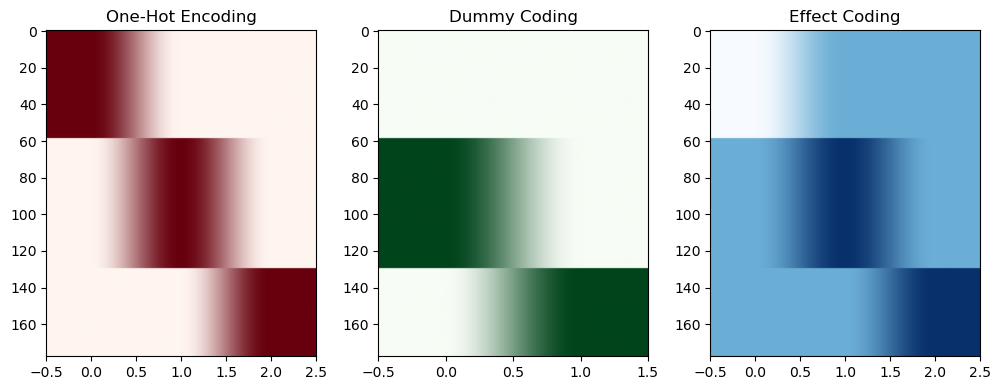

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(df_ohe[ohe_cols],cmap="Reds",aspect="auto")
plt.title("One-Hot Encoding")

plt.subplot(1,3,2)
plt.imshow(df_dummy[["class_1","class_2"]],cmap="Greens",aspect="auto")
plt.title("Dummy Coding")

plt.subplot(1,3,3)
plt.imshow(df_effect[["class_0","class_1","class_2"]],cmap="Blues",aspect="auto")
plt.title("Effect Coding")

plt.tight_layout()
plt.show()